In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings("ignore")

A bizonytalanság megjelenítése (errorbar)

In [4]:
def plot_errorbars(arg, **kws):
    np.random.seed(42)
    x = np.random.normal(0, 1, 100)
    f, axs = plt.subplots(2, figsize=(7, 2), sharex=True, layout="tight")
    sns.pointplot(x=x, errorbar=arg, **kws, capsize=.3, ax=axs[0])
    sns.stripplot(x=x, jitter=.3, ax=axs[1])

Szórás (standard deviation)

Az átlag körüli egy szórás sugarú intervallum

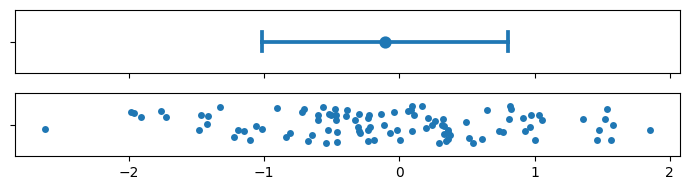

In [ ]:
plot_errorbars('sd')

Percentilis intervallum (percentile interval)

Az adatok adott százaléka esik az intervallumba.

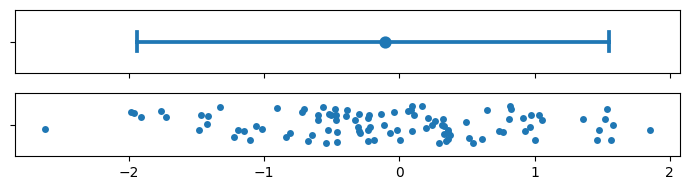

In [ ]:
plot_errorbars(('pi', 95))
# Levágja az első és az utolsó 2.5%-ot, így a maradék 95% közé eső értékek között húz egy vonalat.

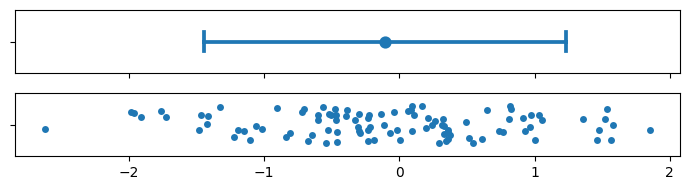

In [ ]:
plot_errorbars(('pi', 85))

Standard hiba

A szórás osztva a minta elemszámának négyzetgyökével.

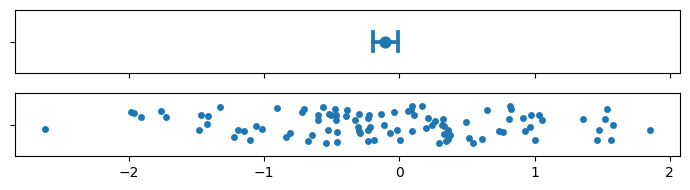

In [ ]:
plot_errorbars('se')
# A szórás / gyök(minta mérete) értékek között húz egy vonalat. Milyen pontosan mérjük a minta átlagát. Több adat -> kisebb szórás

Konfidencia intervallum

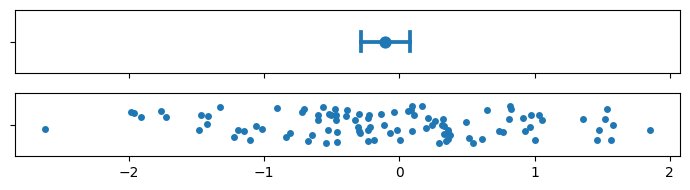

In [12]:
plot_errorbars( 'ci' )
# Ha még 100-szor elvégezzük a mintavételt, 95-ször még ebbe a vonalba esik majd a minta átlaga. Ez a leggyakrabban használt hibasáv típus.

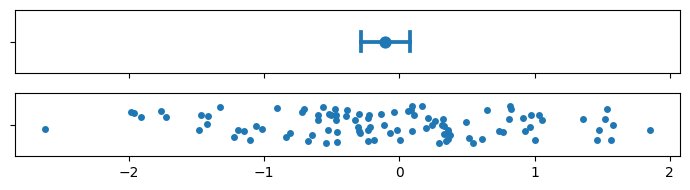

In [ ]:
plot_errorbars(('se', 2))
# A szórás / gyök(minta mérete) értékek között húz egy vonalat. Milyen pontosan mérjük a minta átlagát. Több adat -> kisebb szórás. Itt a vonal a minta átlagától 2 szórásnyira van, így a legtöbb adatpontnak bele kell esnie ebbe a vonalba.

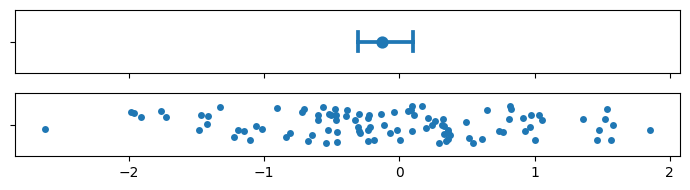

In [14]:
plot_errorbars('ci', estimator='median')
# Ha még 100-szor elvégezzük a mintavételt, 95-ször még ebbe a vonalba esik majd a minta mediánja. Nem az átlag!

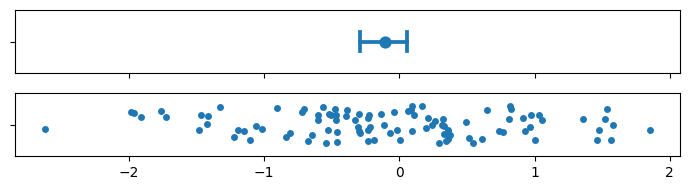

In [15]:
plot_errorbars('ci', n_boot=1000, seed=10)
# A szórás / gyök(minta mérete) értékek között húz egy vonalat. Milyen pontosan mérjük a minta átlagát. Több adat -> kisebb szórás.
# Itt a bootstrapping módszerrel számoljuk ki a hibasávot, így nem feltételezzük, hogy az adatok normális eloszlásúak. Ez a legpontosabb módszer, de sokkal lassabb is.

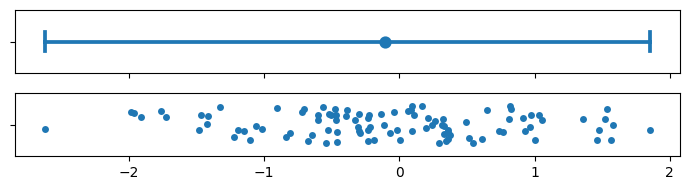

In [16]:
plot_errorbars(lambda x: (x.min(), x.max()))
# A minimum és a maximum értékek között húz egy vonalat. Ez a legkevésbé pontos módszer, de a leggyorsabb is. Nem ajánlott használni, mert nagyon érzékeny az outlierekre.

Példa:
    Generáljunk véletlen értékeket (x)!
    Az y legyen x lineáris függvénye és némi zaj (véletlen érték)!
    Ábrázoljuk y-t x függvényében, a regressziós egyenessel és az ahhoz tartozó 95%-os konfidencia intervallummal!

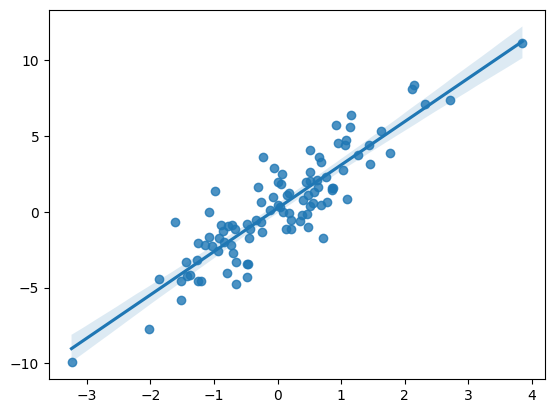

In [ ]:
x = np.random.normal(0, 1, 100)
y = x * 3 + np.random.normal(0, 2, size=x.size)
sns.regplot(x=x, y=y, ci=95) # A regressziós vonal köré 95%-os konfidencia intervallumot rajzol.
plt.show()

Feladat:

Töltsük be az 'fmri' adatbázist és kérjük le az alapvető információkat!

In [18]:
fmri = sns.load_dataset('fmri')

fmri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subject    1064 non-null   object 
 1   timepoint  1064 non-null   int64  
 2   event      1064 non-null   object 
 3   region     1064 non-null   object 
 4   signal     1064 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 41.7+ KB


In [ ]:
fmri.head() # Az első 5 sort mutatja meg a DataFrame-ből. Alapértelmezetten 5 sort mutat, de megadhatunk más számot is.

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


Hányféle érték szerepel az 'event', illetve a 'region' oszlopban? Melyikből mennyi?

In [ ]:
fmri['event'].value_counts() # Kiválasztja az event oszlopot és az abban szereplő értékek gyakoriságát számolja meg.

event
stim    532
cue     532
Name: count, dtype: int64

In [21]:
fmri['region'].value_counts()

region
parietal    532
frontal     532
Name: count, dtype: int64

Ábrázoljuk a 'signal' értékeket az idő ('timepoint') függvényében scatterploton! Mit figyelhetünk meg

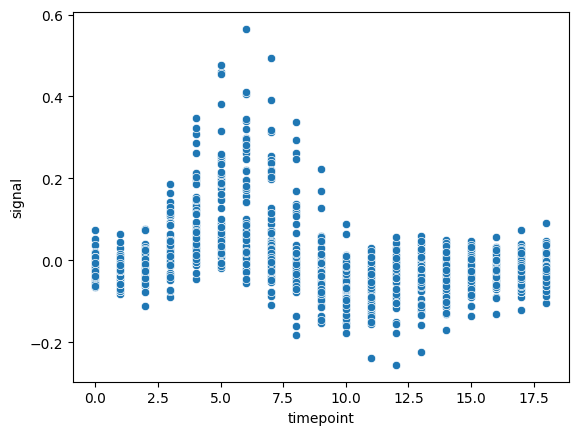

In [ ]:
sns.scatterplot(data=fmri, x='timepoint', y='signal') # A scatterplot egy pontfelhő, ahol minden pont egy megfigyelést reprezentál. Itt a timepoint és a signal értékeket ábrázoljuk.
plt.show()

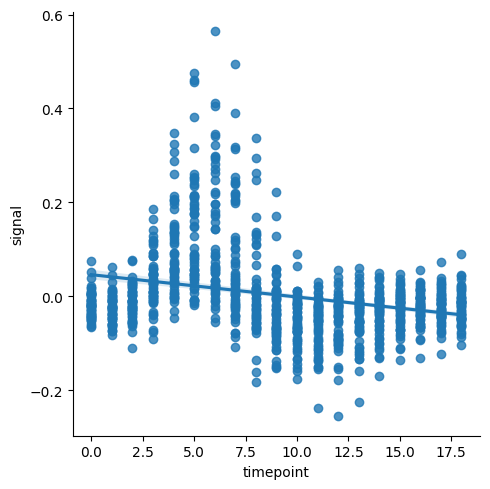

In [ ]:
sns.lmplot(data=fmri, x='timepoint', y='signal') # A lmplot egy lineáris regressziós vonalat rajzol a scatterplot fölé. Ez megmutatja, hogy van-e lineáris kapcsolat a timepoint és a signal között.
plt.show()

Ábrázoljuk a 'signal' értékeket az idő ('timepoint') függvényében lineploton!

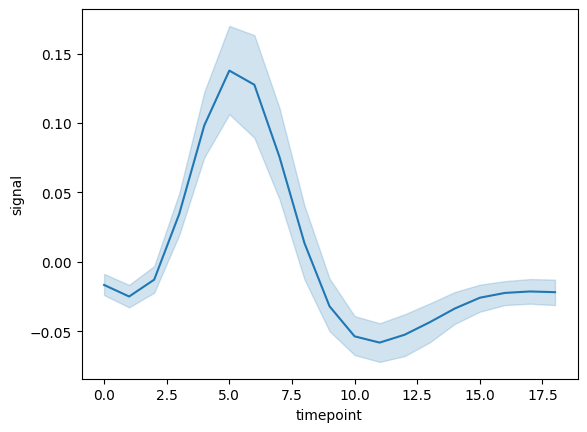

In [24]:
sns.lineplot(data=fmri, x='timepoint', y='signal')
# A lineplot egy vonaldiagram, ahol a pontokat vonalakkal kötjük össze. Ez megmutatja, hogy hogyan változik a signal érték a timepoint értékek függvényében.
plt.show()

Az előző ábrán változtassuk a konfidencia intervallum méretét!

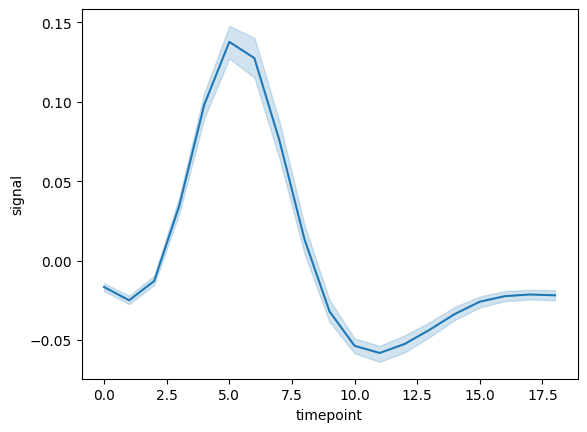

In [ ]:
sns.lineplot(data=fmri, x='timepoint', y='signal', errorbar=('ci', 50))
# A lineplot egy vonaldiagram, ahol a pontokat vonalakkal kötjük össze. Ez megmutatja, hogy hogyan változik a signal érték a timepoint értékek függvényében.
# A vonal köré 50%-os konfidencia intervallumot rajzol.
plt.show()

Konfidencia intervallum helyett használjunk 'percentile interval'-t (pi)!

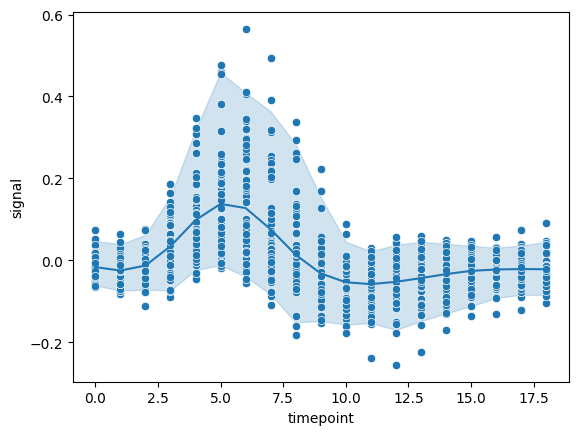

In [26]:
sns.lineplot(data=fmri, x='timepoint', y='signal', errorbar=('pi',95) )
sns.scatterplot(data=fmri, x='timepoint', y='signal')
# A lineplot egy vonaldiagram, ahol a pontokat vonalakkal kötjük össze. Ez megmutatja, hogy hogyan változik a signal érték a timepoint értékek függvényében.
# A vonal köré percentilis hibasávot rajzol, ami azt mutatja meg, hogy a timepoint értékek 95%-a milyen signal értékek között van.
plt.show()

Ábrázoljuk egymás mellett (subplot) a következőket:

    adatok (scatterplot)
    95%-os konfidencia intervallum (lineplot)
    1 standard hibányi intervallum (lineplot)
    95%-os percentilis inztervallum (lineplot)

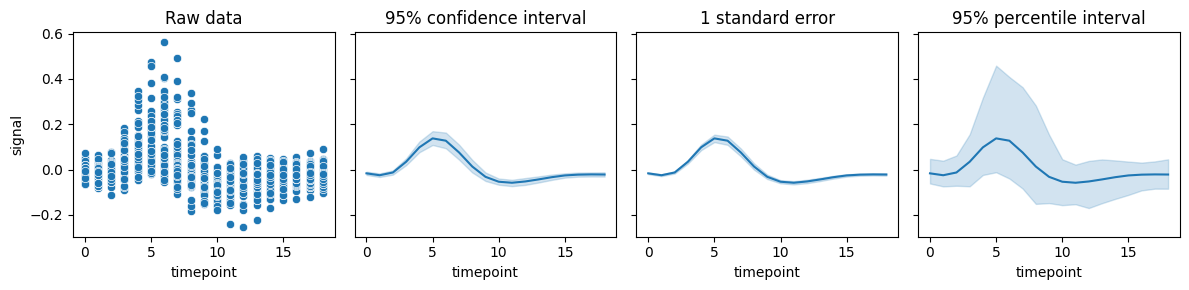

In [27]:
fig, axs = plt.subplots(1,4, figsize=(12, 3), sharex=True, sharey=True, layout="tight")

sns.scatterplot(data=fmri, x='timepoint', y='signal', ax=axs[0])
axs[0].set_title('Raw data')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[1], errorbar=('ci', 95))
axs[1].set_title('95% confidence interval')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[2], errorbar=('se',1))
axs[2].set_title('1 standard error')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[3], errorbar=('pi',95))
axs[3].set_title('95% percentile interval')

plt.show()

Az előző ábráknál nézzük külön az eltérő eseményeket ('event')! (hue)

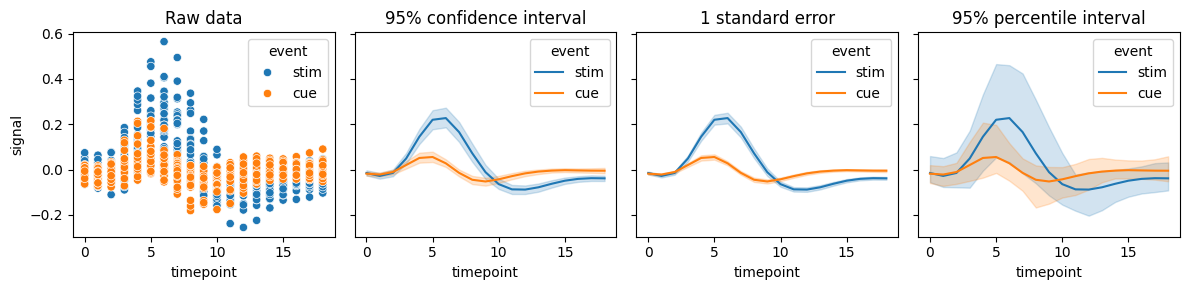

In [28]:
fig, axs = plt.subplots(1,4, figsize=(12, 3), sharex=True, sharey=True, layout="tight")

sns.scatterplot(data=fmri, x='timepoint', y='signal', ax=axs[0], hue="event")
axs[0].set_title('Raw data')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[1], hue='event', errorbar=('ci', 95))
axs[1].set_title('95% confidence interval')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[2], hue='event', errorbar=('se',1))
axs[2].set_title('1 standard error')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[3], hue='event', errorbar=('pi',95))
axs[3].set_title('95% percentile interval')

plt.show()

Az 'event'-en kívül tekintsük az eltérő régiókat ('region') is! (hue, style)
Használjunk 2×2-es subplotot!

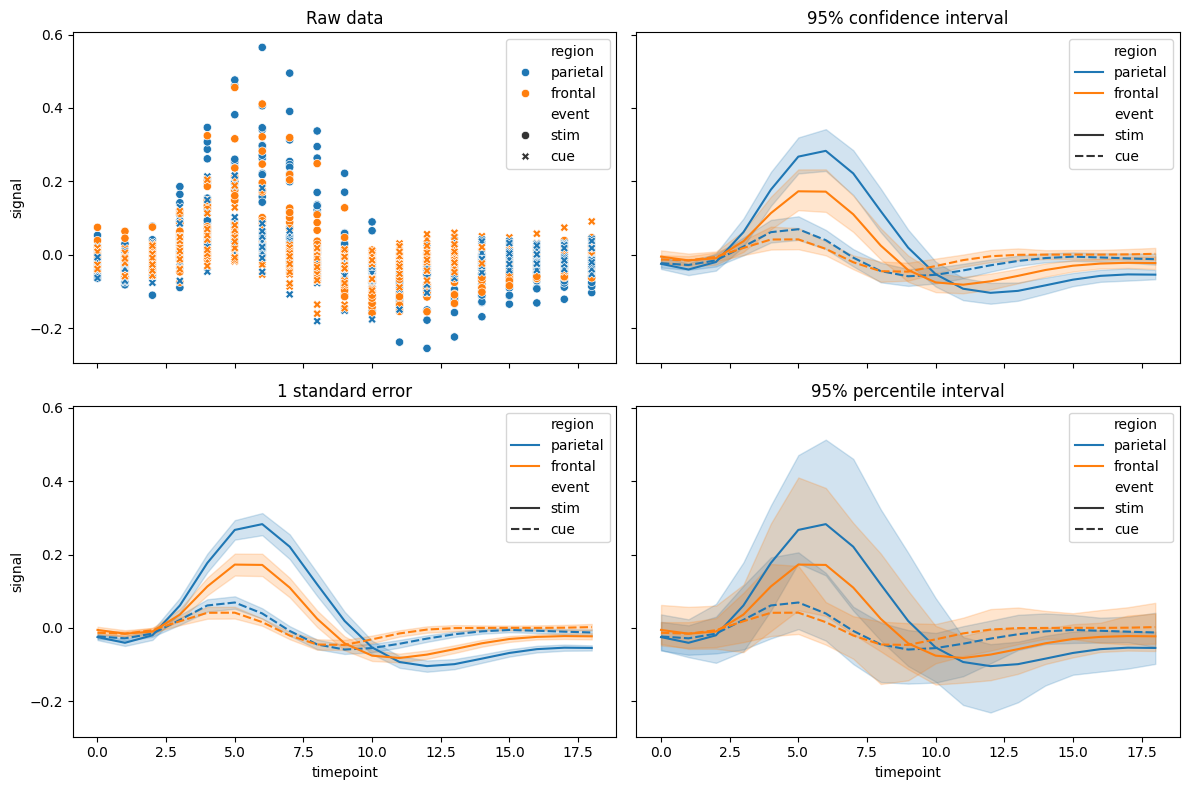

In [29]:
fig, axs = plt.subplots(2,2, figsize=(12, 8), sharex=True, sharey=True, layout="tight")

sns.scatterplot(data=fmri, x='timepoint', y='signal', ax=axs[0,0], hue='region', style='event')
axs[0,0].set_title('Raw data')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[0,1], hue='region', style='event', errorbar=('ci', 95))
axs[0,1].set_title('95% confidence interval')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[1,0], hue='region', style='event', errorbar=('se',1))
axs[1,0].set_title('1 standard error')

sns.lineplot(data=fmri, x='timepoint', y='signal', ax=axs[1,1], hue='region', style='event', errorbar=('pi',95))
axs[1,1].set_title('95% percentile interval')

plt.show()

Kernel density

Játszadozzunk a kdeplottal! Kis adathalmaz esetén változtassuk a sávszélesség értékét (bw_adjust)! Mit tapasztalunk?

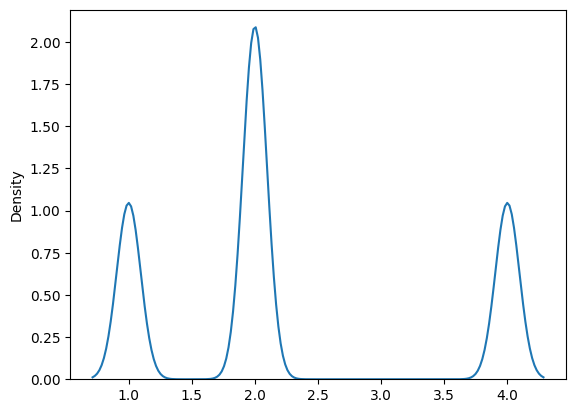

In [30]:
xx = [1,2,2,4]

# változtassuk a 'bw_adjust' értékét:
sns.kdeplot(data=xx, bw_adjust=0.1)
plt.show()